# Tema 3: Efeito do Escalonamento do Meta-alvo em Sistemas de Meta-aprendizagem

**Objetivo:** Investigar o impacto de técnicas de escalonamento (normalização/padronização) aplicadas diretamente ao **meta-alvo** (performances dos algoritmos de nível base) na performance do meta-modelo preditivo.

**Perguntas de pesquisa:**
1. Existe diferença *relevante* no desempenho do meta-modelo ao variar a técnica de escalonamento do meta-alvo?
2. Há uma recomendação geral que funcione para qualquer meta-modelo?

**Referência:** Amorim et al. (2022), *"The choice of scaling technique matters for classification performance"*

---


## Seção 0 — Setup e Dependências

In [71]:
# Instala dependências (silencioso)
import subprocess, sys
pkgs = ['scikit-learn', 'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'openml', 'nbformat', 'pymfe']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print("✓ Dependências verificadas.")


✓ Dependências verificadas.


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
import copy
warnings.filterwarnings('ignore')

# scikit-learn — datasets
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits

# scikit-learn — modelo/avaliação
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, QuantileTransformer, LabelEncoder)

# algoritmos base (classificação)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, SVR

# meta-regressores
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

# métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_classif

# scipy
from scipy.stats import entropy, pearsonr, friedmanchisquare, wilcoxon, spearmanr

# openml
import openml
openml.config.apikey = ''          # sem API key — apenas datasets públicos

# ── Configurações globais ──────────────────────────────────────────────────
DATA_DIR = Path('dados')
DATA_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_DATASETS_TARGET = 200  # Número total de datasets desejados no cache
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid', palette='muted')

print("✓ Importações concluídas!")

✓ Importações concluídas!


## Seção 1 — Coleta e Armazenamento dos Datasets

Utilizou-se datasets **reais** de classificação provenientes exclusivamente do **OpenML**, filtrados de acordo com os seguintes critérios:
- Número de instâncias: $100 \le N \le 2000$
- Número de atributos: $3 \le D \le 50$
- Número de classes: $2 \le C \le 10$
- Sem famílias de datasets

Obtêm-se os N_DATASETS_TARGET primeiros datasets que atendem a esses critérios. Um arquivo geral com todos os datasets é salvo como `.csv` na pasta `dados/` para fins de reprodutibilidade e cache local.

In [73]:
# ── 1a. Coleta e Armazenamento dos Datasets ───────────────────────────────
from sklearn.preprocessing import LabelEncoder
import time, random
from pathlib import Path
import queue
import threading

# ─── CONFIGURAÇÃO DA API KEY DO OPENML (OPCIONAL) ───────
OPENML_API_KEY = ''
if OPENML_API_KEY:
    openml.config.apikey = OPENML_API_KEY

DATASETS_DIR = DATA_DIR / 'datasets'
DATASETS_DIR.mkdir(exist_ok=True, parents=True)

datasets = {}

def _process_openml_dataset(oml_dataset):
    '''Converte um objeto openml.Dataset em DataFrame padronizado.'''
    X_raw, y_raw, _, _ = oml_dataset.get_data(
        dataset_format='dataframe',
        target=oml_dataset.default_target_attribute
    )
    if X_raw is None or y_raw is None:
        return None
    X_df = pd.DataFrame(X_raw)
    cat_cols = X_df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)
    X_df = X_df.astype(float)
    le = LabelEncoder()
    if isinstance(y_raw, pd.DataFrame):
        y_raw = y_raw.iloc[:, 0]
    y_enc = le.fit_transform(y_raw.astype(str))
    df = X_df.copy()
    df['target'] = y_enc
    df = df.dropna()
    feature_cols = [c for c in df.columns if c != 'target']
    rename_dict = {old: f'f{i}' for i, old in enumerate(feature_cols)}
    df = df.rename(columns=rename_dict)
    return df

def fetch_with_retry(did, max_retries=5, base_delay=2.0):
    '''Baixa dataset do OpenML com retry+backoff para erros 503/transientes.'''
    for attempt in range(max_retries):
        try:
            oml_dataset = openml.datasets.get_dataset(
                did,
                download_data=True,
                download_qualities=False,
                download_features_meta_data=False
            )
            return oml_dataset
        except Exception as e:
            err_str = str(e)
            if any(code in err_str for code in ['503', '502', '429', 'Connection', 'Timeout', 'timed out']):
                if attempt < max_retries - 1:
                    wait = base_delay * (2 ** attempt) + random.uniform(0, 1)
                    print(f'    ↻ Tentativa {attempt+1}/{max_retries} falhou (503/rede). Aguardando {wait:.1f}s...')
                    time.sleep(wait)
                    continue
            raise
    raise RuntimeError(f'Falha após {max_retries} tentativas para dataset {did}')

# Fila thread-safe leve (contém apenas strings/inteiros de metadados)
download_queue = queue.Queue(maxsize=10)

def downloader_worker(candidates, datasets_dict, target_limit=N_DATASETS_TARGET):
    '''Thread Produtora: Baixa datasets do OpenML para o disco e enfileira metadados leves.'''
    for candidate in candidates:
        if len(datasets_dict) >= target_limit:
            break
            
        did = int(candidate['did'])
        name = candidate['name']
        key = f'openml_{name}_{did}'
        
        # Ignora se já está no cache carregado
        if key in datasets_dict:
            continue
            
        try:
            # Garante o download no disco (I/O bound)
            fetch_with_retry(did)
            # Enfileira apenas metadados leves (sem carregar o dataset inteiro na fila)
            download_queue.put((key, name, did, None))
        except Exception as e:
            download_queue.put((key, name, did, e))
            
    # Sinaliza fim da fila
    download_queue.put(None)

def processor_worker(datasets_dict, failed_list, target_limit=N_DATASETS_TARGET):
    '''Thread Consumidora: Consome da fila, carrega o dataset do disco, processa e valida.'''
    while True:
        item = download_queue.get()
        if item is None:
            download_queue.task_done()
            break
            
        key, name, did, err = item
        
        if len(datasets_dict) >= target_limit:
            download_queue.task_done()
            continue
            
        if isinstance(err, Exception):
            err_msg = str(err)[:80]
            failed_list.append((did, name, err_msg))
            print(f'  [Falha Download] {name} (ID: {did}): ✗ {err_msg[:60]}')
            download_queue.task_done()
            continue
            
        print(f'  [{len(datasets_dict)+1}/{N_DATASETS_TARGET}] Processando {name} (ID: {did})...', end=' ', flush=True)
        try:
            # Carrega do cache local em disco de forma instantânea
            oml_dataset = openml.datasets.get_dataset(
                did,
                download_data=False,
                download_qualities=False,
                download_features_meta_data=False
            )
            df = _process_openml_dataset(oml_dataset)
            if df is None:
                print('✗ (sem dados pós-processamento)')
                download_queue.task_done()
                continue
                                
            # Salva no cache individual limpo
            file_path = DATASETS_DIR / f'{key}.csv'
            df.to_csv(file_path, index=False)
            datasets_dict[key] = df
            print(f'✓ shape={df.shape}')
            
        except Exception as e:
            err_msg = str(e)[:80]
            failed_list.append((did, name, err_msg))
            print(f'✗ {err_msg[:60]}')
            
        download_queue.task_done()

# 1. Carrega datasets existentes do cache local
if DATASETS_DIR.exists():
    for file_path in DATASETS_DIR.glob('openml_*.csv'):
        try:
            df_dataset = pd.read_csv(file_path)
            datasets[file_path.stem] = df_dataset
        except Exception as e:
            print(f"  ⚠ Erro ao carregar {file_path.name}: {e}")

print(f'✓ {len(datasets)} datasets carregados do cache local (dados/datasets/).')

# 2. Busca novos datasets se tivermos menos de N_DATASETS_TARGET
if len(datasets) >= N_DATASETS_TARGET:
    print(f"Você já possui {N_DATASETS_TARGET} ou mais datasets válidos carregados no cache.")
else:
    print('Buscando catálogo de tarefas de classificação no OpenML...')
    df_tasks = openml.tasks.list_tasks(task_type=openml.tasks.TaskType.SUPERVISED_CLASSIFICATION, output_format='dataframe')
    df_tasks = df_tasks.drop_duplicates(subset=['did'])

    criteria = (
        (df_tasks['NumberOfInstances'] >= 100) & (df_tasks['NumberOfInstances'] <= 2000) &
        (df_tasks['NumberOfFeatures'] >= 3) & (df_tasks['NumberOfFeatures'] <= 50) &
        (df_tasks['NumberOfClasses'] >= 2) & (df_tasks['NumberOfClasses'] <= 10) &
        (df_tasks['status'] == 'active')
    )
    df_tasks = df_tasks[criteria]

    # Evita famílias redundantes
    df_tasks['family'] = df_tasks['name'].str.split(r'[_|-]').str[0]
    df_tasks = df_tasks.drop_duplicates(subset=['family'])

    all_candidates = df_tasks.to_dict('records')
    print(f'Datasets candidatos no catálogo (após filtrar famílias): {len(all_candidates)}')
    
    failed = []
    
    # Inicia Threads Produtor e Consumidor
    producer = threading.Thread(target=downloader_worker, args=(all_candidates, datasets, N_DATASETS_TARGET))
    consumer = threading.Thread(target=processor_worker, args=(datasets, failed, N_DATASETS_TARGET))
    
    producer.start()
    consumer.start()
    
    # Aguarda a conclusão
    producer.join()
    consumer.join()

    print(f'\nFinalizado! {len(datasets)} datasets válidos carregados.')
    if failed:
        print(f'Falhas ({len(failed)}): {[n for _, n, _ in failed]}')


✓ 200 datasets carregados do cache local (dados/datasets/).
Você já possui 200 ou mais datasets válidos carregados no cache.


## Seção 2 — Extração de Meta-features (X)

Para cada dataset, extraímos **8 meta-features** que caracterizam a base de dados:

| # | Meta-feature | Descrição |
|---|---|---|
| 1 | N (instâncias) | Número de amostras |
| 2 | D (atributos) | Número de features |
| 3 | D/N | Razão features/amostras |
| 4 | Imbalance Ratio (IR) | max_count / min_count entre classes |
| 5 | Entropia de Shannon | Grau de equilíbrio entre classes |
| 6 | Correlação de Pearson média | |r| médio entre pares de features |
| 7 | Variância média | Média da variância por feature |
| 8 | Informação mútua média | Média da MI entre features e alvo |


In [74]:
# ── Extração de Meta-features via PyMFE ─────────────────────────────────
from pymfe.mfe import MFE
import numpy as np
import pandas as pd

# ── Extrai meta-features para todos os datasets utilizando o PyMFE ────────
meta_features_rows = []
valid_datasets = []   # datasets que passaram na extração

# Inicializa o extrator PyMFE com os grupos desejados
mfe = MFE(groups=["general", "statistical", "info-theory", "clustering"], random_state=RANDOM_STATE)

for ds_name, df in datasets.items():
    try:
        y = df['target'].values.astype(int)
        X = df.drop(columns=['target']).values.astype(float)

        # Remove colunas constantes ou totalmente NaN do dataset de entrada
        valid_cols = ~(np.all(np.isnan(X), axis=0) | (np.nanstd(X, axis=0) < 1e-12))
        X = X[:, valid_cols]

        # Imputa NaN com a mediana da coluna no dataset original se restarem valores ausentes
        if np.any(np.isnan(X)):
            col_medians = np.nanmedian(X, axis=0)
            nan_mask = np.isnan(X)
            if np.any(np.isnan(col_medians)):
                col_medians = np.nan_to_num(col_medians, nan=0.0)
            for col_idx in range(X.shape[1]):
                X[nan_mask[:, col_idx], col_idx] = col_medians[col_idx]

        if X.shape[1] == 0:
            print(f"  ⚠ {ds_name}: sem features válidas após limpeza")
            continue

        # Executa a extração via PyMFE
        mfe.fit(X, y)
        ft_names, ft_values = mfe.extract()
        
        # Cria dicionário de meta-features para este dataset
        mf_dict = dict(zip(ft_names, ft_values))
        mf_dict['dataset'] = ds_name
        
        meta_features_rows.append(mf_dict)
        valid_datasets.append({'name': ds_name, 'X': X, 'y': y})

    except Exception as e:
        print(f"  ✗ {ds_name}: {e}")

# Cria DataFrame de meta-features
X_meta = pd.DataFrame(meta_features_rows).set_index('dataset')

# Substitui valores infinitos por NaN nas meta-features
X_meta = X_meta.replace([np.inf, -np.inf], np.nan)
# Substitui valores excessivamente grandes por NaN (evita overflow no StandardScaler)
for col in X_meta.columns:
    try:
        # Valores muito grandes (ex: > 1e10) podem causar estouro/overflow ao serem elevados ao quadrado no StandardScaler
        X_meta.loc[X_meta[col].abs() > 1e10, col] = np.nan
    except Exception:
        pass

# Trata potenciais NaN gerados pelo PyMFE nas próprias meta-features
# 1. Remove colunas de meta-features que tenham apenas NaN ou valor constante
constant_or_nan_cols = []
for col in X_meta.columns:
    if X_meta[col].isna().all() or X_meta[col].nunique() <= 1:
        constant_or_nan_cols.append(col)
X_meta = X_meta.drop(columns=constant_or_nan_cols)

# 2. Imputa valores ausentes (NaN) residuais nas meta-features com a mediana da coluna
for col in X_meta.columns:
    if X_meta[col].isna().any():
        median_val = X_meta[col].median()
        if pd.isna(median_val):
            median_val = 0.0
        X_meta[col] = X_meta[col].fillna(median_val)

X_meta.to_csv(DATA_DIR / 'meta_features.csv')

print(f"\n✓ Meta-features extraídas via PyMFE para {len(X_meta)} datasets.")
print(f"  Shape de X_meta: {X_meta.shape}")
X_meta.describe().round(4)



✓ Meta-features extraídas via PyMFE para 200 datasets.
  Shape de X_meta: (200, 78)


,attr_conc.mean,attr_conc.sd,attr_ent.mean,attr_ent.sd,attr_to_inst,can_cor.mean,can_cor.sd,ch,class_conc.mean,class_conc.sd,...,skewness.sd,sparsity.mean,sparsity.sd,t_mean.mean,t_mean.sd,var.mean,var.sd,vdb,vdu,w_lambda
count,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,...,200.0000,200.0000,200.0000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,200.0000,200.0000,200.0000
mean,0.0825,0.0872,1.6180,0.5066,0.1951,0.6268,0.2088,75.3393,0.0708,0.0654,...,2.4607,0.2419,0.0982,5.283826e+06,1.841738e+07,1.013697e+08,2.030304e+08,8.7207,0.0000,0.4624
std,0.0901,0.0753,0.9205,0.3983,0.6934,0.2296,0.0724,157.8959,0.0993,0.0708,...,2.5067,0.1988,0.0889,7.368167e+07,2.344562e+08,5.611297e+08,9.706812e+08,19.8159,0.0001,0.3158
min,-0.0000,0.0000,0.0000,0.0000,0.0020,0.0199,0.0000,0.0019,0.0000,0.0000,...,0.0000,0.0000,0.0000,-2.970000e-02,0.000000e+00,7.600000e-03,0.000000e+00,0.5114,0.0000,0.0000
25%,0.0159,0.0304,0.8379,0.0985,0.0232,0.4718,0.2090,4.3208,0.0111,0.0097,...,0.6289,0.0287,0.0098,2.221000e+00,4.108400e+00,1.763700e+00,2.935300e+00,1.8975,0.0000,0.1819
50%,0.0484,0.0680,1.5444,0.4717,0.0488,0.6396,0.2090,16.5585,0.0344,0.0322,...,1.6287,0.2584,0.0831,1.931990e+01,3.717190e+01,1.632913e+02,3.105826e+02,3.5424,0.0000,0.4640
75%,0.1188,0.1375,2.3841,0.8153,0.0980,0.7930,0.2090,68.4680,0.0869,0.1017,...,3.4791,0.4382,0.1827,1.429527e+02,5.115260e+02,8.999641e+04,2.572382e+05,7.3801,0.0000,0.7512
max,0.5000,0.3722,3.5821,1.5239,7.1436,1.0000,0.5638,1224.5105,0.5932,0.3244,...,16.0893,0.4997,0.2617,1.041992e+09,3.295067e+09,5.028722e+09,7.424344e+09,171.5702,0.0015,0.9996


## Seção 3 — Extração do Meta-alvo (Y)

O meta-alvo é a **performance dos algoritmos de classificação de nível base** em cada dataset.

**Algoritmos base avaliados:**
- KNN (k=5)
- Decision Tree (CART)
- Random Forest (100 estimadores)
- Gaussian Naive Bayes
- SVM (kernel RBF)

**Protocolo:** Validação cruzada estratificada com 5 folds → métrica: **F1-score Macro** médio.

O resultado é uma matriz **Y** de shape `(N_datasets × 5)`.

In [75]:
# ── Definição dos algoritmos base ─────────────────────────────────────────
BASE_CLASSIFIERS = {
    'KNN':          KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100,
                                           random_state=RANDOM_STATE,
                                           n_jobs=-1),
    'GaussianNB':   GaussianNB(),
    'SVM':          SVC(kernel='rbf', random_state=RANDOM_STATE),
}

cv_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Algoritmos base:")
for name in BASE_CLASSIFIERS:
    print(f"  • {name}")

# ── Avalia algoritmos base em cada dataset ────────────────────────────────
# ⏳ Esta célula pode levar alguns minutos dependendo do número de datasets.

meta_target_rows = []

for i, ds_info in enumerate(valid_datasets):
    name = ds_info['name']
    X    = ds_info['X']
    y    = ds_info['y']

    row = {'dataset': name}
    for clf_name, clf in BASE_CLASSIFIERS.items():
        try:
            scores = cross_val_score(
                clf, X, y,
                cv=cv_base,
                scoring='f1_macro',
                n_jobs=-1
            )
            row[clf_name] = round(float(scores.mean()), 6)
        except Exception as e:
            row[clf_name] = np.nan
            print(f"  ✗ {name}/{clf_name}: {e}")

    meta_target_rows.append(row)
    print(f"  [{i+1:3d}/{len(valid_datasets)}] {name}: "
          + " | ".join(f"{k}={v:.4f}" for k, v in row.items() if k != 'dataset'))

Y_meta = pd.DataFrame(meta_target_rows).set_index('dataset')
Y_meta.to_csv(DATA_DIR / 'meta_target.csv')

print(f"\n✓ Meta-alvo extraído. Shape: {Y_meta.shape}")
Y_meta.describe().round(4)


Algoritmos base:
  • KNN
  • DecisionTree
  • RandomForest
  • GaussianNB
  • SVM


  [  1/200] openml_1StudentPerfromance_43255: KNN=0.8542 | DecisionTree=0.8126 | RandomForest=0.8415 | GaussianNB=0.6625 | SVM=0.8704
  [  2/200] openml_acute-inflammations_1556: KNN=1.0000 | DecisionTree=1.0000 | RandomForest=1.0000 | GaussianNB=0.8157 | SVM=0.3828
  [  3/200] openml_algerian_forest_fires_46279: KNN=0.8894 | DecisionTree=0.9792 | RandomForest=0.9875 | GaussianNB=0.9459 | SVM=0.9068
  [  4/200] openml_analcatdata_boxing2_444: KNN=0.6686 | DecisionTree=0.6560 | RandomForest=0.7214 | GaussianNB=0.7475 | SVM=0.7936
  [  5/200] openml_anneal_2: KNN=0.6293 | DecisionTree=0.9352 | RandomForest=0.9726 | GaussianNB=0.8014 | SVM=0.1729
  [  6/200] openml_appendicitis_test_edsa_45613: KNN=0.7790 | DecisionTree=0.6923 | RandomForest=0.7783 | GaussianNB=0.7805 | SVM=0.7333
  [  7/200] openml_ar1_1059: KNN=0.4759 | DecisionTree=0.5711 | RandomForest=0.5472 | GaussianNB=0.5908 | SVM=0.4807
  [  8/200] openml_ar4_1061: KNN=0.6571 | DecisionTree=0.6980 | RandomForest=0.7126 | Gaussian

,KNN,DecisionTree,RandomForest,GaussianNB,SVM
count,199.0000,199.0000,199.0000,199.0000,198.0000
mean,0.6538,0.7204,0.7337,0.6432,0.5894
std,0.1968,0.1851,0.1908,0.2099,0.2391
min,0.1354,0.2080,0.1573,0.0146,0.0484
25%,0.5111,0.5834,0.5801,0.5031,0.4265
50%,0.6433,0.7021,0.7351,0.6484,0.5547
75%,0.8001,0.8929,0.9161,0.7973,0.7871
max,1.0000,1.0000,1.0000,1.0000,1.0000


In [76]:
# ── Alinha X e Y (remove datasets com NaN no meta-alvo) ──────────────────
common_idx = X_meta.index.intersection(Y_meta.index)

X_meta_clean = X_meta.loc[common_idx].dropna()
Y_meta_clean = Y_meta.loc[X_meta_clean.index].dropna()
common_idx    = X_meta_clean.index.intersection(Y_meta_clean.index)

X_meta_clean = X_meta_clean.loc[common_idx]
Y_meta_clean = Y_meta_clean.loc[common_idx]

X_arr = X_meta_clean.values.astype(float)
Y_arr = Y_meta_clean.values.astype(float)
N     = len(common_idx)

print(f"✓ Datasets válidos para o pipeline meta: {N}")
print(f"  X_meta shape: {X_arr.shape}")
print(f"  Y_meta shape: {Y_arr.shape}")
print(f"\nDistribuição do F1-macro (todos os algoritmos base):")
print(Y_meta_clean.describe().round(4))


✓ Datasets válidos para o pipeline meta: 198
  X_meta shape: (198, 78)
  Y_meta shape: (198, 5)

Distribuição do F1-macro (todos os algoritmos base):
            KNN  DecisionTree  RandomForest  GaussianNB       SVM
count  198.0000      198.0000      198.0000    198.0000  198.0000
mean     0.6521        0.7190        0.7323      0.6414    0.5894
std      0.1958        0.1844        0.1903      0.2089    0.2391
min      0.1354        0.2080        0.1573      0.0146    0.0484
25%      0.5110        0.5831        0.5796      0.5006    0.4265
50%      0.6432        0.7019        0.7340      0.6468    0.5547
75%      0.7972        0.8922        0.9142      0.7956    0.7871
max      1.0000        1.0000        1.0000      1.0000    1.0000


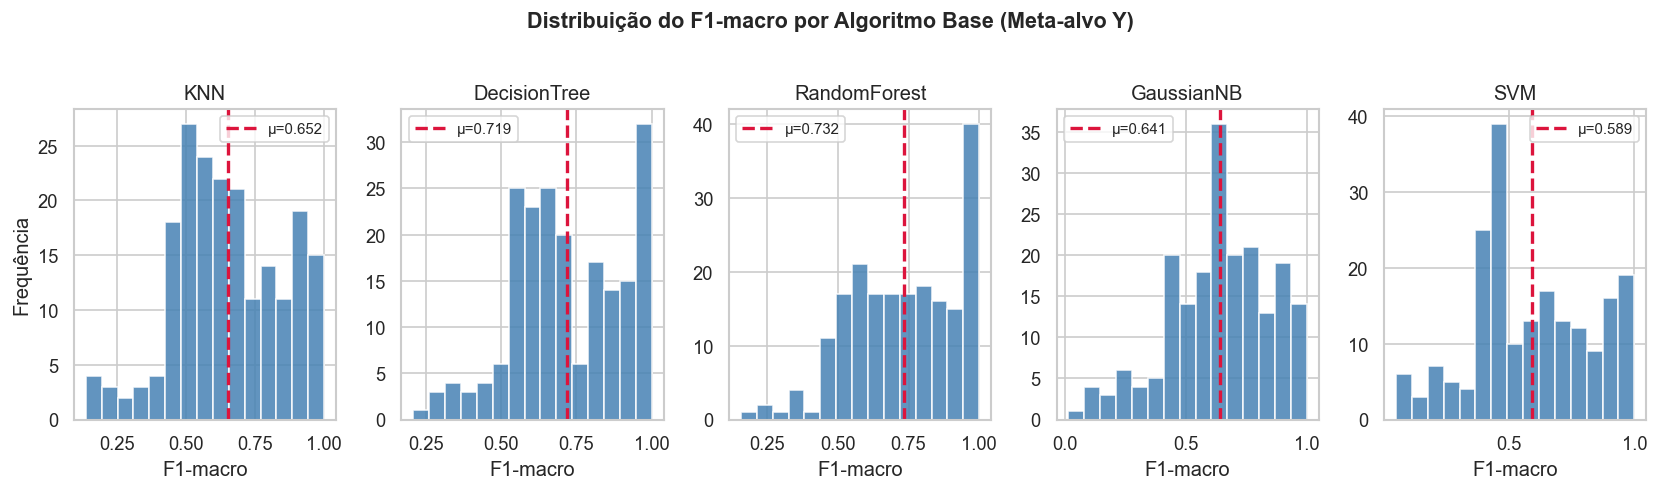

In [77]:
# ── Visualiza distribuição do meta-alvo ───────────────────────────────────
fig, axes = plt.subplots(1, len(BASE_CLASSIFIERS), figsize=(14, 4), sharey=False)
alg_names = list(BASE_CLASSIFIERS.keys())

for ax, alg in zip(axes, alg_names):
    vals = Y_meta_clean[alg].dropna()
    ax.hist(vals, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='crimson', lw=2, linestyle='--',
               label=f'μ={vals.mean():.3f}')
    ax.set_title(alg)
    ax.set_xlabel('F1-macro')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuição do F1-macro por Algoritmo Base (Meta-alvo Y)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'distribuicao_meta_alvo.png', bbox_inches='tight')
plt.show()


## Seção 4 — Pipeline de Meta-aprendizagem com Escalonamento do Meta-alvo

### Protocolo

Para cada combinação de **meta-modelo × scaler do alvo**, executamos:

1. **Validação cruzada de 5 folds** no nível meta (linhas = datasets).
2. Em cada fold:
   - Scale de X com `StandardScaler` (ajustado no treino).
   - Scale de Y com o scaler em teste (ajustado **somente** no treino — sem *look-ahead bias*).
   - Treinamento do meta-modelo em `(X_train_scaled, Y_train_scaled)`.
   - Predição de `Y_pred_scaled` no conjunto de teste.
   - **Inversão** do scaler: `Y_pred = scaler⁻¹(Y_pred_scaled)`.
   - Cálculo das métricas na escala original de F1.

### Técnicas de escalonamento testadas

| Técnica | Tipo |
|---|---|
| Baseline | Sem escalonamento |
| StandardScaler | Linear — Z-score |
| MinMaxScaler | Linear — [0, 1] |
| RobustScaler | Linear — mediana/IQR |
| QuantileTransformer | Não-linear — distribuição normal |

### Meta-modelos avaliados

| Meta-modelo | Notas |
|---|---|
| Ridge (α=1.0) | Regressão linear regularizada |
| SVR (RBF, C=1.0, ε=0.1) | Insensível à escala dos parâmetros absolutos |
| Random Forest Regressor | Baseado em árvores — insensível ao scaler |
| MLP Regressor (16, 8) | Rede neural — altamente sensível |

### Métricas avaliadas (escala original)

- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **Spearman** — Correlação de Spearman entre ranking predito e real (por dataset)
- **Acc@1** — Proporção de datasets em que o melhor algoritmo previsto == melhor real


In [78]:
# ── Definição de meta-modelos e scalers ───────────────────────────────────

def make_scalers():
    """Retorna dict de fábricas de scalers (callable → instância nova)."""
    return {
        'Baseline':            None,
        'StandardScaler':      lambda: StandardScaler(),
        'MinMaxScaler':        lambda: MinMaxScaler(),
        'RobustScaler':        lambda: RobustScaler(),
        'QuantileTransformer': lambda: QuantileTransformer(
                                    output_distribution='normal',
                                    random_state=RANDOM_STATE),
    }

def make_meta_models():
    """Retorna dict com instâncias dos meta-regressores."""
    return {
        'Ridge': Ridge(alpha=1.0),
        'SVR':   SVR(kernel='rbf', C=1.0, epsilon=0.1),
        'RandomForest': RandomForestRegressor(
                            n_estimators=100,
                            random_state=RANDOM_STATE,
                            n_jobs=-1),
        'MLP': MLPRegressor(
                    hidden_layer_sizes=(16, 8),
                    solver='adam',
                    max_iter=2000,
                    random_state=RANDOM_STATE),
    }

SCALERS      = make_scalers()
META_MODELS  = make_meta_models()
SCALER_NAMES = list(SCALERS.keys())
MODEL_NAMES  = list(META_MODELS.keys())

print("Meta-modelos:", MODEL_NAMES)
print("Scalers:     ", SCALER_NAMES)


Meta-modelos: ['Ridge', 'SVR', 'RandomForest', 'MLP']
Scalers:      ['Baseline', 'StandardScaler', 'MinMaxScaler', 'RobustScaler', 'QuantileTransformer']


In [79]:
# ── Funções de métricas por dataset ───────────────────────────────────────

def spearman_per_row(y_true_row: np.ndarray, y_pred_row: np.ndarray) -> float:
    """
    Correlação de Spearman entre as performances reais e previstas
    dos M algoritmos base para um único dataset.
    Requer pelo menos 3 algoritmos.
    """
    if len(y_true_row) < 3:
        return np.nan
    r, _ = spearmanr(y_true_row, y_pred_row)
    return float(r) if not np.isnan(r) else 0.0


def acc_at_1(y_true_row: np.ndarray, y_pred_row: np.ndarray) -> float:
    """1 se o algoritmo previsto como melhor é de fato o melhor, 0 caso contrário."""
    return float(np.argmax(y_true_row) == np.argmax(y_pred_row))


def predict_multioutput(model, model_name: str,
                        X_tr, Y_tr_sc, X_te) -> np.ndarray:
    """
    Treina e prediz. SVR não suporta multi-output nativamente →
    treina uma instância por coluna.
    """
    if model_name == 'SVR':
        preds = []
        for col in range(Y_tr_sc.shape[1]):
            m = copy.deepcopy(model)
            m.fit(X_tr, Y_tr_sc[:, col])
            preds.append(m.predict(X_te))
        return np.column_stack(preds)
    else:
        m = copy.deepcopy(model)
        m.fit(X_tr, Y_tr_sc)
        return m.predict(X_te)

print("✓ Funções de métricas definidas.")


✓ Funções de métricas definidas.


In [80]:
# ── Pipeline principal ────────────────────────────────────────────────────
# ⏳ Esta é a célula mais lenta — executa 5 × 4 × 5 = 100 combinações de CV.

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Estrutura de resultados: per-dataset arrays, indexados pelo idx global do dataset
# results[model_name][scaler_name] = {
#     'mae':      np.array(N,),  # MAE por dataset
#     'rmse':     np.array(N,),
#     'spearman': np.array(N,),
#     'acc1':     np.array(N,),
# }
results = {mn: {sn: {'mae': np.full(N, np.nan),
                      'rmse': np.full(N, np.nan),
                      'spearman': np.full(N, np.nan),
                      'acc1': np.full(N, np.nan)}
                for sn in SCALER_NAMES}
           for mn in MODEL_NAMES}

scalers     = make_scalers()
meta_models = make_meta_models()

total_combos = len(MODEL_NAMES) * len(SCALER_NAMES)
combo_idx    = 0

for model_name, model_proto in meta_models.items():
    for scaler_name, scaler_factory in scalers.items():
        combo_idx += 1

        for train_idx, test_idx in kf.split(X_arr):
            X_train, X_test = X_arr[train_idx].copy(), X_arr[test_idx].copy()
            Y_train, Y_test = Y_arr[train_idx].copy(), Y_arr[test_idx].copy()

            # Substitui infinitos e valores excessivamente grandes por NaN e depois imputa pela mediana do treino
            for col_idx in range(X_train.shape[1]):
                train_col = X_train[:, col_idx]
                bad_train = np.isinf(train_col) | (np.abs(train_col) > 1e10) | np.isnan(train_col)
                if np.any(bad_train):
                    median_val = np.nanmedian(train_col[~bad_train]) if np.any(~bad_train) else 0.0
                    if np.isnan(median_val) or np.isinf(median_val):
                        median_val = 0.0
                    X_train[bad_train, col_idx] = median_val
                else:
                    median_val = np.median(train_col)
                
                test_col = X_test[:, col_idx]
                bad_test = np.isinf(test_col) | (np.abs(test_col) > 1e10) | np.isnan(test_col)
                if np.any(bad_test):
                    X_test[bad_test, col_idx] = median_val

            # Clip de segurança para prevenir overflow no StandardScaler
            X_train = np.clip(X_train, -1e10, 1e10)
            X_test = np.clip(X_test, -1e10, 1e10)

            # ── Scale X (sempre StandardScaler) ───────────────────────────
            x_sc = StandardScaler()
            X_tr_sc = x_sc.fit_transform(X_train)
            X_te_sc = x_sc.transform(X_test)

            # ── Scale Y (scaler do meta-alvo) ─────────────────────────────
            if scaler_factory is not None:
                y_sc      = scaler_factory()
                Y_tr_sc   = y_sc.fit_transform(Y_train)
            else:
                y_sc    = None
                Y_tr_sc = Y_train.copy()

            # ── Treina e prediz ────────────────────────────────────────────
            Y_pred_sc = predict_multioutput(
                model_proto, model_name, X_tr_sc, Y_tr_sc, X_te_sc
            )

            # ── Inversão do scaler ─────────────────────────────────────────
            if y_sc is not None:
                Y_pred = y_sc.inverse_transform(Y_pred_sc)
            else:
                Y_pred = Y_pred_sc.copy()
            Y_pred = np.clip(Y_pred, 0.0, 1.0)

            # ── Métricas por dataset de teste ─────────────────────────────
            for k, ds_idx in enumerate(test_idx):
                yt = Y_test[k]      # shape (M,)
                yp = Y_pred[k]      # shape (M,)
                results[model_name][scaler_name]['mae'][ds_idx]      = (
                    float(np.mean(np.abs(yt - yp))))
                results[model_name][scaler_name]['rmse'][ds_idx]     = (
                    float(np.sqrt(np.mean((yt - yp) ** 2))))
                results[model_name][scaler_name]['spearman'][ds_idx] = (
                    spearman_per_row(yt, yp))
                results[model_name][scaler_name]['acc1'][ds_idx]     = (
                    acc_at_1(yt, yp))

        # Progresso
        mae_m = np.nanmean(results[model_name][scaler_name]['mae'])
        sp_m  = np.nanmean(results[model_name][scaler_name]['spearman'])
        ac_m  = np.nanmean(results[model_name][scaler_name]['acc1'])
        print(f"  [{combo_idx:3d}/{total_combos}] {model_name:15s} | {scaler_name:22s} | "
              f"MAE={mae_m:.4f}  Spearman={sp_m:.4f}  Acc@1={ac_m:.4f}")

print("\n✓ Pipeline concluído!")


  [  1/20] Ridge           | Baseline               | MAE=0.1007  Spearman=0.4966  Acc@1=0.3788
  [  2/20] Ridge           | StandardScaler         | MAE=0.1007  Spearman=0.4966  Acc@1=0.3788
  [  3/20] Ridge           | MinMaxScaler           | MAE=0.1007  Spearman=0.4966  Acc@1=0.3788
  [  4/20] Ridge           | RobustScaler           | MAE=0.1007  Spearman=0.4966  Acc@1=0.3788
  [  5/20] Ridge           | QuantileTransformer    | MAE=0.1152  Spearman=0.4483  Acc@1=0.3586
  [  6/20] SVR             | Baseline               | MAE=0.0978  Spearman=0.5213  Acc@1=0.3687
  [  7/20] SVR             | StandardScaler         | MAE=0.0898  Spearman=0.5982  Acc@1=0.4949
  [  8/20] SVR             | MinMaxScaler           | MAE=0.0952  Spearman=0.5447  Acc@1=0.4192
  [  9/20] SVR             | RobustScaler           | MAE=0.0884  Spearman=0.5966  Acc@1=0.4646
  [ 10/20] SVR             | QuantileTransformer    | MAE=0.0896  Spearman=0.5847  Acc@1=0.4293
  [ 11/20] RandomForest    | Baseline   

In [81]:
# ── Tabela de resultados consolidada ──────────────────────────────────────
summary_rows = []
for model_name in MODEL_NAMES:
    for scaler_name in SCALER_NAMES:
        r = results[model_name][scaler_name]
        summary_rows.append({
            'Meta-Modelo':        model_name,
            'Scaler':             scaler_name,
            'MAE (μ)':            round(float(np.nanmean(r['mae'])),    4),
            'RMSE (μ)':           round(float(np.nanmean(r['rmse'])),   4),
            'Spearman (μ)':       round(float(np.nanmean(r['spearman'])), 4),
            'Acc@1 (μ)':          round(float(np.nanmean(r['acc1'])),   4),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(DATA_DIR / 'resultados_pipeline.csv', index=False)

# Highlight mínimo MAE e máximo Spearman/Acc@1 por modelo
def highlight_best(df_group):
    df_styled = df_group.style \
        .highlight_min(subset=['MAE (μ)'],     color='#c6efce') \
        .highlight_max(subset=['Spearman (μ)', 'Acc@1 (μ)'], color='#c6efce') \
        .format({'MAE (μ)': '{:.4f}', 'RMSE (μ)': '{:.4f}',
                 'Spearman (μ)': '{:.4f}', 'Acc@1 (μ)': '{:.4f}'})
    return df_styled

print("Tabela de resultados consolidada:")
summary_df


Tabela de resultados consolidada:


,Meta-Modelo,Scaler,MAE (μ),RMSE (μ),Spearman (μ),Acc@1 (μ)
0,Ridge,Baseline,0.1007,0.1163,0.4966,0.3788
1,Ridge,StandardScaler,0.1007,0.1163,0.4966,0.3788
2,Ridge,MinMaxScaler,0.1007,0.1163,0.4966,0.3788
3,Ridge,RobustScaler,0.1007,0.1163,0.4966,0.3788
4,Ridge,QuantileTransformer,0.1152,0.1358,0.4483,0.3586
5,SVR,Baseline,0.0978,0.1100,0.5213,0.3687
6,SVR,StandardScaler,0.0898,0.1024,0.5982,0.4949
7,SVR,MinMaxScaler,0.0952,0.1074,0.5447,0.4192
8,SVR,RobustScaler,0.0884,0.1009,0.5966,0.4646
9,SVR,QuantileTransformer,0.0896,0.1033,0.5847,0.4293


## Seção 5 — Análise Estatística

### Protocolo
- **Teste de Friedman** (global): verifica se há diferença significativa de MAE entre os 5 scalers, para cada meta-modelo.  
  - H₀: todos os scalers produzem a mesma distribuição de MAE.  
  - p < 0.05 → diferença global significativa.
- **Teste de Wilcoxon signed-rank** (post-hoc): compara pairwise cada scaler com o **Baseline** (sem escalonamento).  
  - p < 0.05 → scaler X difere significativamente do baseline.

Os testes são aplicados sobre os **N vetores de MAE por dataset** (uma observação por dataset).


In [82]:
# ── Testes de Friedman por meta-modelo ────────────────────────────────────
from scipy.stats import friedmanchisquare, wilcoxon

ALPHA = 0.05

friedman_results = {}

print("=" * 70)
print(f"{'Teste de Friedman — H0: todos os scalers são equivalentes':^70}")
print("=" * 70)

for model_name in MODEL_NAMES:
    # MAE por dataset para cada scaler
    mae_arrays = [results[model_name][sn]['mae'] for sn in SCALER_NAMES]

    # Remove NaN (datasets que falharam)
    valid_mask = ~np.any(np.isnan(np.column_stack(mae_arrays)), axis=1)
    mae_clean  = [arr[valid_mask] for arr in mae_arrays]

    stat, p = friedmanchisquare(*mae_clean)
    friedman_results[model_name] = {'stat': stat, 'p': p, 'significant': p < ALPHA}

    sig_str = '✓ SIGNIFICATIVO' if p < ALPHA else '✗ não significativo'
    print(f"\n{model_name}:")
    print(f"  χ²  = {stat:.4f}   p-value = {p:.4e}   [{sig_str}]")

print("\n" + "=" * 70)


      Teste de Friedman — H0: todos os scalers são equivalentes       

Ridge:
  χ²  = 22.3760   p-value = 1.6868e-04   [✓ SIGNIFICATIVO]

SVR:
  χ²  = 53.9152   p-value = 5.4824e-11   [✓ SIGNIFICATIVO]

RandomForest:
  χ²  = 4.5778   p-value = 3.3342e-01   [✗ não significativo]

MLP:
  χ²  = 278.0238   p-value = 5.9437e-59   [✓ SIGNIFICATIVO]



In [83]:
# ── Testes de Wilcoxon post-hoc (cada scaler vs. Baseline) ───────────────
print("=" * 75)
print(f"{'Wilcoxon signed-rank — comparação de cada scaler vs. Baseline':^75}")
print("=" * 75)

wilcoxon_results = {}

for model_name in MODEL_NAMES:
    wilcoxon_results[model_name] = {}
    baseline_mae = results[model_name]['Baseline']['mae']

    print(f"\n{model_name} (Friedman p={friedman_results[model_name]['p']:.4e}):")
    print(f"  {'Scaler':25s}  {'W-stat':>8}  {'p-value':>12}  {'Δ MAE':>10}  Conclusão")
    print("  " + "-" * 65)

    for scaler_name in SCALER_NAMES:
        if scaler_name == 'Baseline':
            continue

        comp_mae = results[model_name][scaler_name]['mae']

        # Alinha removendo NaN
        valid = ~(np.isnan(baseline_mae) | np.isnan(comp_mae))
        b_clean = baseline_mae[valid]
        c_clean = comp_mae[valid]

        if len(b_clean) < 5:
            print(f"  {scaler_name:25s}  — amostras insuficientes —")
            continue

        try:
            stat, p = wilcoxon(b_clean, c_clean)
        except Exception:
            stat, p = np.nan, np.nan

        delta = np.mean(c_clean) - np.mean(b_clean)
        sig   = '✓ sig.' if p < ALPHA else '✗ n.s.'
        direction = '↓ melhora' if delta < 0 else ('↑ piora' if delta > 0 else '= igual')
        wilcoxon_results[model_name][scaler_name] = {
            'stat': stat, 'p': p, 'delta_mae': delta
        }
        print(f"  {scaler_name:25s}  {stat:8.2f}  {p:12.4e}  {delta:+10.4f}  {sig} {direction}")


       Wilcoxon signed-rank — comparação de cada scaler vs. Baseline       

Ridge (Friedman p=1.6868e-04):
  Scaler                       W-stat       p-value       Δ MAE  Conclusão
  -----------------------------------------------------------------
  StandardScaler              7501.00    2.4607e-01     +0.0000  ✗ n.s. ↑ piora
  MinMaxScaler                7489.50    4.8142e-02     +0.0000  ✓ sig. ↑ piora
  RobustScaler                7630.50    1.1801e-01     +0.0000  ✗ n.s. ↑ piora
  QuantileTransformer         6395.00    1.8674e-05     +0.0145  ✓ sig. ↑ piora

SVR (Friedman p=5.4824e-11):
  Scaler                       W-stat       p-value       Δ MAE  Conclusão
  -----------------------------------------------------------------
  StandardScaler              6452.00    2.5585e-05     -0.0080  ✓ sig. ↓ melhora
  MinMaxScaler                5041.00    2.5640e-09     -0.0026  ✓ sig. ↓ melhora
  RobustScaler                5571.00    1.1527e-07     -0.0093  ✓ sig. ↓ melhora
  Quantile

## Seção 6 — Visualizações e Tabela Final


In [84]:
# ── 6a. Tabela estilizada por meta-modelo ─────────────────────────────────
for model_name in MODEL_NAMES:
    sub = summary_df[summary_df['Meta-Modelo'] == model_name].copy()
    sub = sub.drop(columns='Meta-Modelo').set_index('Scaler')

    # Identifica melhores valores
    best_mae      = sub['MAE (μ)'].idxmin()
    best_spearman = sub['Spearman (μ)'].idxmax()
    best_acc1     = sub['Acc@1 (μ)'].idxmax()

    print(f"\n{'─'*60}")
    print(f"  {model_name}")
    print(f"{'─'*60}")
    print(sub.to_string())
    print(f"  ★ Melhor MAE:      {best_mae}")
    print(f"  ★ Melhor Spearman: {best_spearman}")
    print(f"  ★ Melhor Acc@1:    {best_acc1}")



────────────────────────────────────────────────────────────
  Ridge
────────────────────────────────────────────────────────────
                     MAE (μ)  RMSE (μ)  Spearman (μ)  Acc@1 (μ)
Scaler                                                         
Baseline              0.1007    0.1163        0.4966     0.3788
StandardScaler        0.1007    0.1163        0.4966     0.3788
MinMaxScaler          0.1007    0.1163        0.4966     0.3788
RobustScaler          0.1007    0.1163        0.4966     0.3788
QuantileTransformer   0.1152    0.1358        0.4483     0.3586
  ★ Melhor MAE:      Baseline
  ★ Melhor Spearman: Baseline
  ★ Melhor Acc@1:    Baseline

────────────────────────────────────────────────────────────
  SVR
────────────────────────────────────────────────────────────
                     MAE (μ)  RMSE (μ)  Spearman (μ)  Acc@1 (μ)
Scaler                                                         
Baseline              0.0978    0.1100        0.5213     0.3687
StandardSc

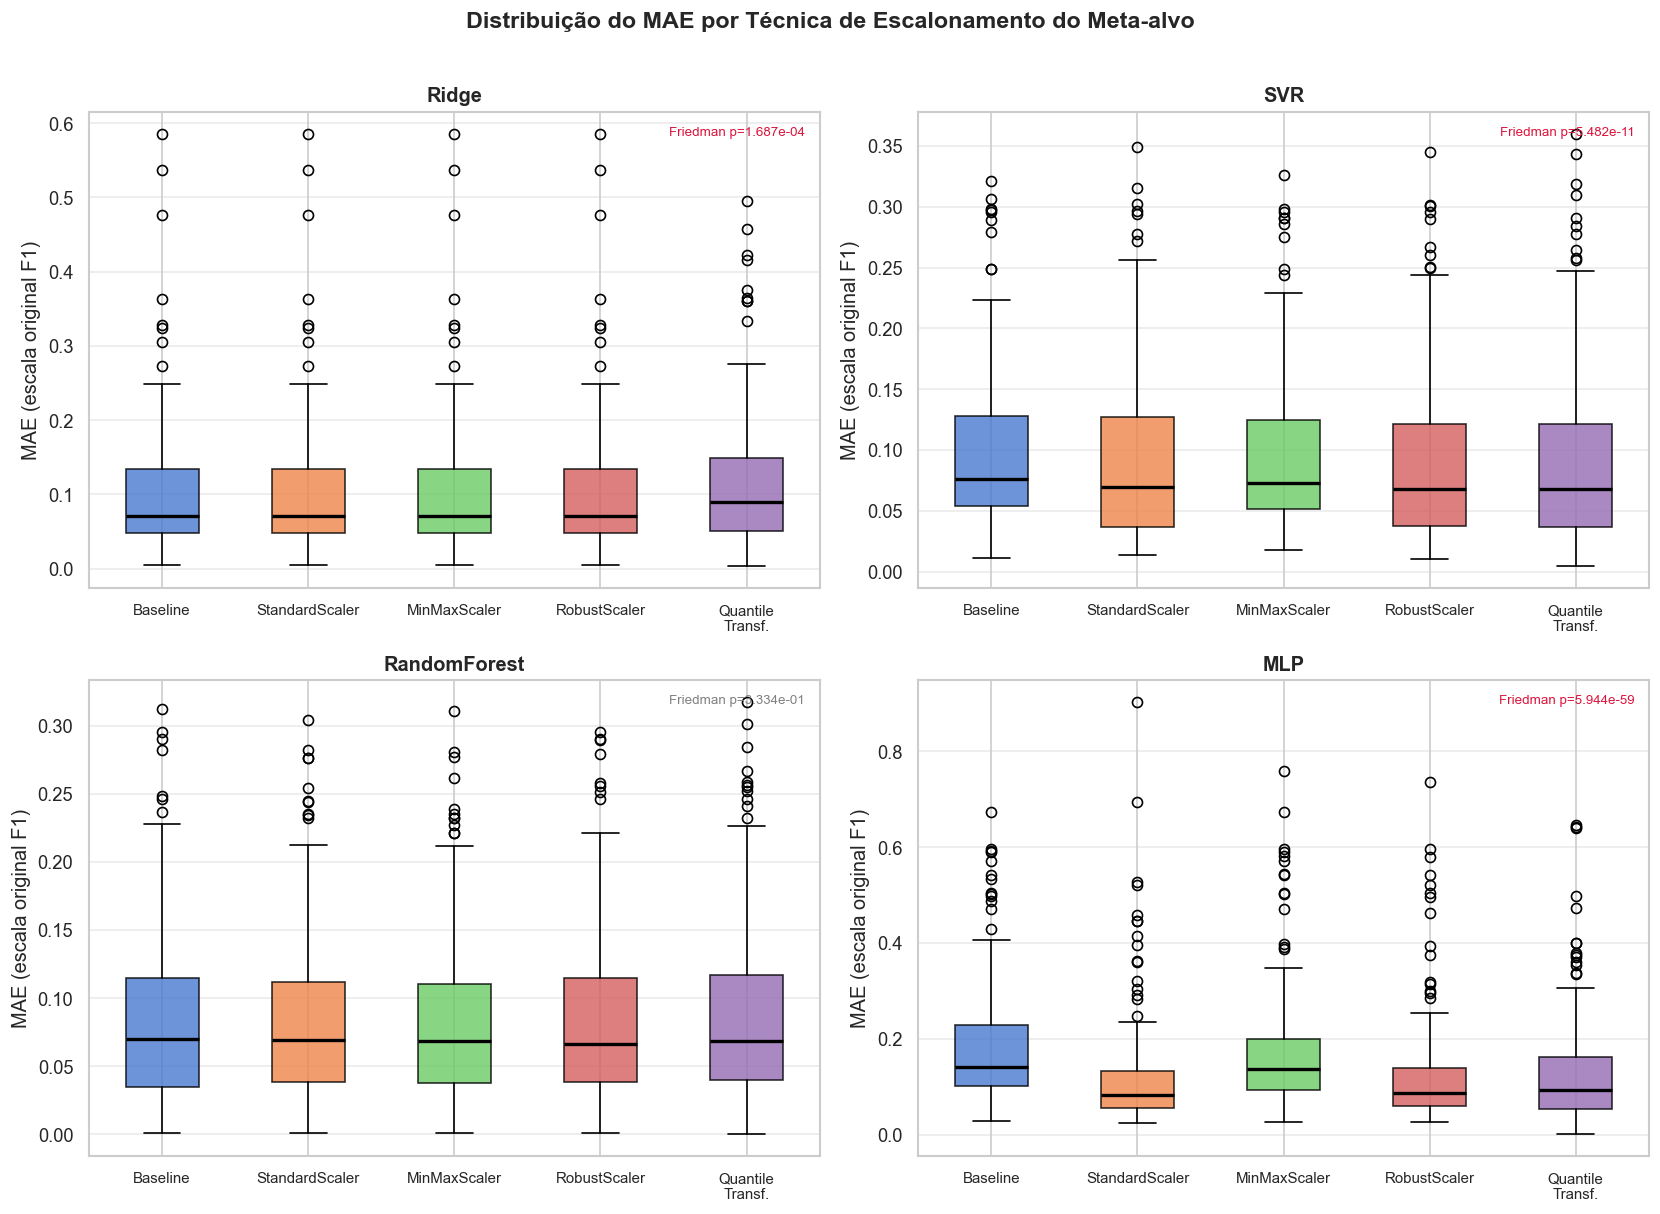

In [85]:
# ── 6b. Boxplots de MAE por Scaler × Meta-modelo ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat  = axes.flatten()

palette = sns.color_palette('muted', n_colors=len(SCALER_NAMES))

for ax, model_name in zip(axes_flat, MODEL_NAMES):
    box_data   = []
    box_labels = []

    for sn in SCALER_NAMES:
        vals = results[model_name][sn]['mae']
        vals_clean = vals[~np.isnan(vals)]
        box_data.append(vals_clean)
        box_labels.append(sn.replace('Transformer', '\nTransf.'))

    bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))

    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_ylabel('MAE (escala original F1)')
    ax.set_xticklabels(box_labels, fontsize=9)
    ax.grid(axis='y', alpha=0.4)

    # Anota Friedman p-value
    fp = friedman_results[model_name]['p']
    sig_str = f'Friedman p={fp:.3e}'
    ax.text(0.98, 0.97, sig_str, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='crimson' if fp < ALPHA else 'gray')

fig.suptitle('Distribuição do MAE por Técnica de Escalonamento do Meta-alvo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'boxplot_mae.png', bbox_inches='tight')
plt.show()


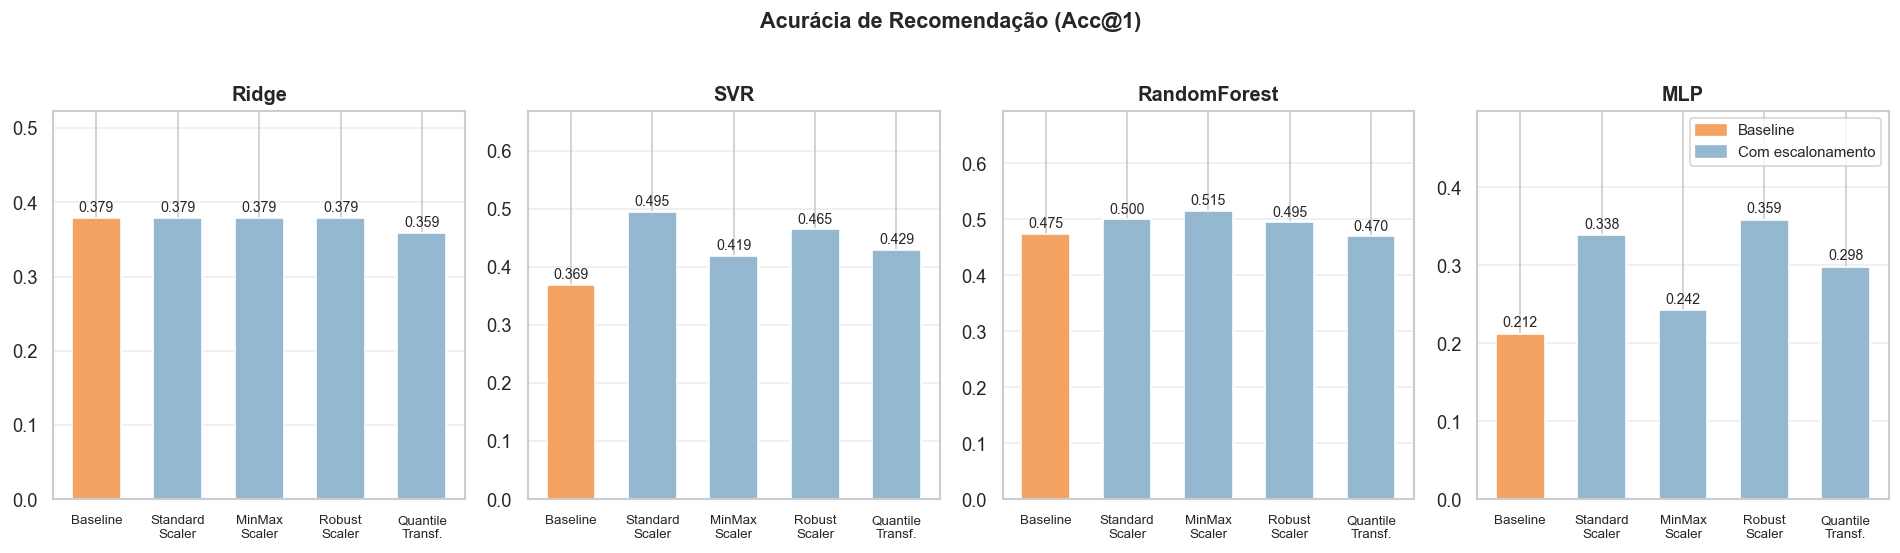

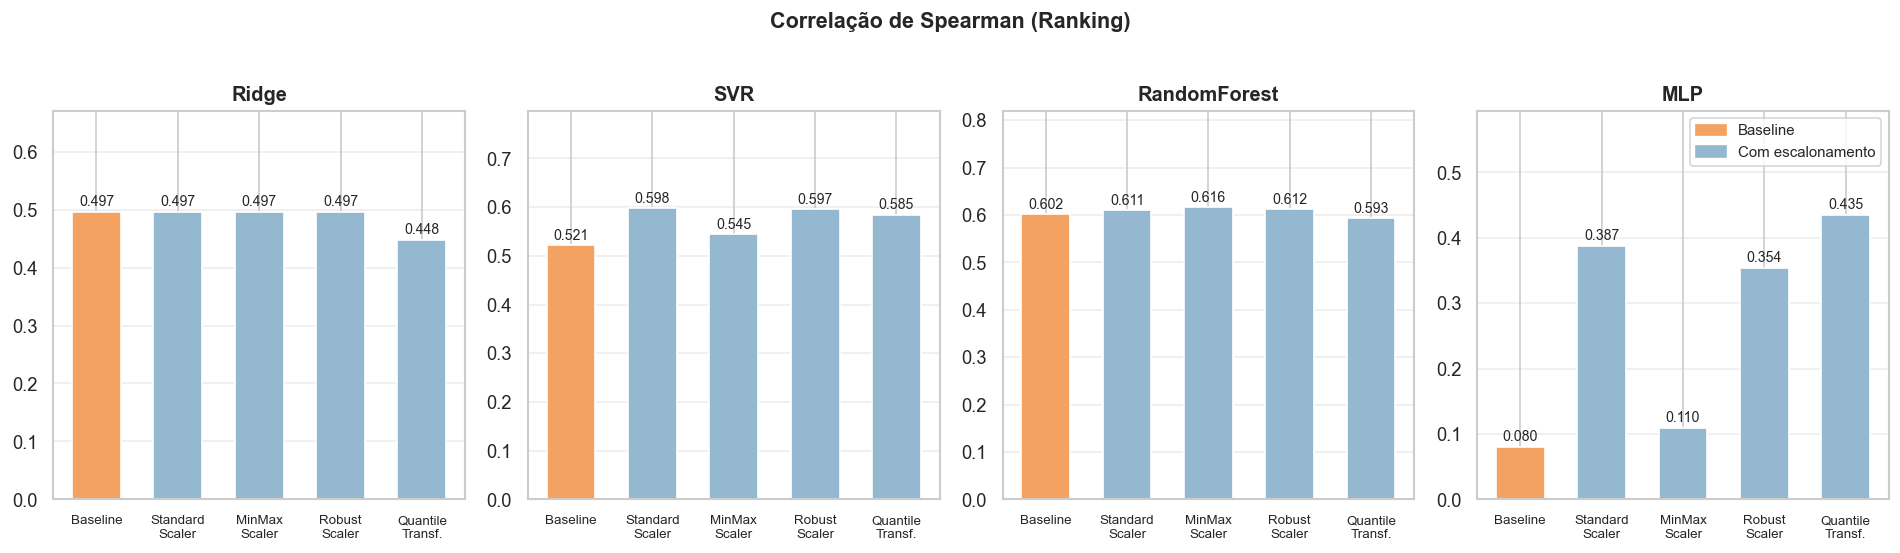

In [86]:
# ── 6c. Gráfico de barras: Acc@1 e Spearman por Scaler ───────────────────
metrics_to_plot = [('Acc@1 (μ)', 'acc1', 'Acurácia de Recomendação (Acc@1)'),
                   ('Spearman (μ)', 'spearman', 'Correlação de Spearman (Ranking)')]

for col_key, result_key, metric_title in metrics_to_plot:
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(16, 4.5), sharey=False)
    x = np.arange(len(SCALER_NAMES))
    width = 0.6

    for ax, model_name in zip(axes, MODEL_NAMES):
        vals = [np.nanmean(results[model_name][sn][result_key])
                for sn in SCALER_NAMES]
        colors_bar = ['#95b8d1' if sn != 'Baseline' else '#f4a261'
                      for sn in SCALER_NAMES]

        bars = ax.bar(x, vals, width=width, color=colors_bar, edgecolor='white')

        # Anota os valores
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

        ax.set_title(model_name, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([sn.replace('Transformer', '\nTransf.')
                             .replace('Scaler', '\nScaler')
                             for sn in SCALER_NAMES], fontsize=8)
        ax.set_ylim(0, min(1.05, max(vals) * 1.25 + 0.05))
        ax.grid(axis='y', alpha=0.35)

    # Legenda de cores
    patch_base  = mpatches.Patch(color='#f4a261', label='Baseline')
    patch_scale = mpatches.Patch(color='#95b8d1', label='Com escalonamento')
    axes[-1].legend(handles=[patch_base, patch_scale], loc='upper right', fontsize=9)

    fig.suptitle(metric_title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fname = f"barras_{result_key}.png"
    plt.savefig(DATA_DIR / fname, bbox_inches='tight')
    plt.show()


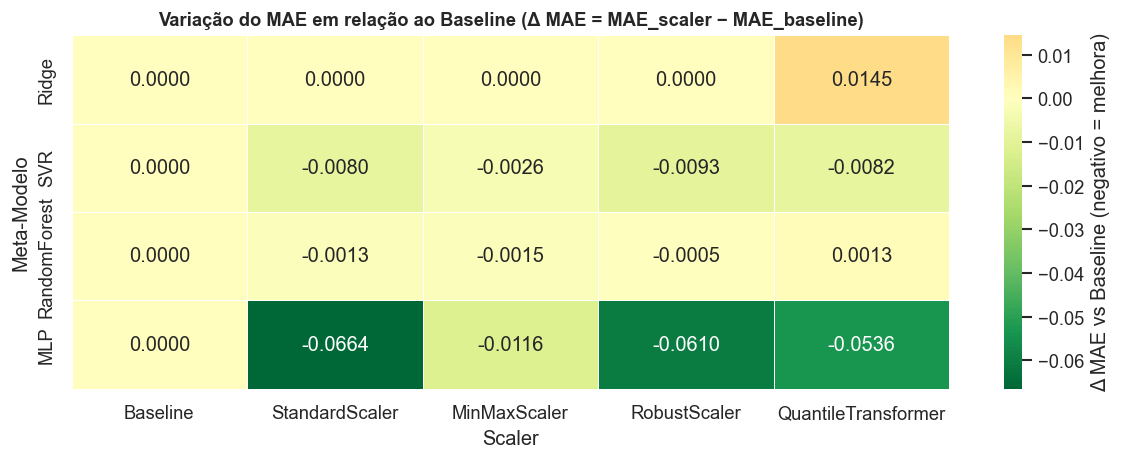

In [87]:
# ── 6d. Heatmap: Δ MAE (scaler vs. baseline) ─────────────────────────────
delta_data = {}
for model_name in MODEL_NAMES:
    baseline_mean = np.nanmean(results[model_name]['Baseline']['mae'])
    row = {}
    for sn in SCALER_NAMES:
        if sn == 'Baseline':
            row[sn] = 0.0
        else:
            row[sn] = np.nanmean(results[model_name][sn]['mae']) - baseline_mean
    delta_data[model_name] = row

delta_df = pd.DataFrame(delta_data).T   # models × scalers
delta_df.columns.name  = 'Scaler'
delta_df.index.name    = 'Meta-Modelo'

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(delta_df, annot=True, fmt='.4f', center=0,
            cmap='RdYlGn_r',   # vermelho = piora, verde = melhora
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Δ MAE vs Baseline (negativo = melhora)'})
ax.set_title('Variação do MAE em relação ao Baseline (Δ MAE = MAE_scaler − MAE_baseline)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'heatmap_delta_mae.png', bbox_inches='tight')
plt.show()


In [88]:
# ── 6e. Resumo final: ranking de scalers por meta-modelo ─────────────────
print("=" * 65)
print("RESUMO FINAL — Melhor Scaler por Meta-Modelo e Métrica")
print("=" * 65)

for model_name in MODEL_NAMES:
    sub = summary_df[summary_df['Meta-Modelo'] == model_name].set_index('Scaler')
    best = {
        'MAE mínimo':        sub['MAE (μ)'].idxmin(),
        'Spearman máximo':   sub['Spearman (μ)'].idxmax(),
        'Acc@1 máximo':      sub['Acc@1 (μ)'].idxmax(),
    }
    fp  = friedman_results[model_name]['p']
    sig = '✓ diferença significativa' if fp < ALPHA else '✗ diferença não significativa'
    print(f"\n{model_name}  (Friedman: {sig}, p={fp:.3e})")
    for metric, winner in best.items():
        mae_val = sub.loc[winner, 'MAE (μ)']
        sp_val  = sub.loc[winner, 'Spearman (μ)']
        a1_val  = sub.loc[winner, 'Acc@1 (μ)']
        print(f"  {metric:20s}: {winner:22s}  "
              f"[MAE={mae_val:.4f}, Sp={sp_val:.4f}, Acc@1={a1_val:.4f}]")

print("\n" + "=" * 65)
print("Arquivos salvos em:", DATA_DIR.resolve())


RESUMO FINAL — Melhor Scaler por Meta-Modelo e Métrica

Ridge  (Friedman: ✓ diferença significativa, p=1.687e-04)
  MAE mínimo          : Baseline                [MAE=0.1007, Sp=0.4966, Acc@1=0.3788]
  Spearman máximo     : Baseline                [MAE=0.1007, Sp=0.4966, Acc@1=0.3788]
  Acc@1 máximo        : Baseline                [MAE=0.1007, Sp=0.4966, Acc@1=0.3788]

SVR  (Friedman: ✓ diferença significativa, p=5.482e-11)
  MAE mínimo          : RobustScaler            [MAE=0.0884, Sp=0.5966, Acc@1=0.4646]
  Spearman máximo     : StandardScaler          [MAE=0.0898, Sp=0.5982, Acc@1=0.4949]
  Acc@1 máximo        : StandardScaler          [MAE=0.0898, Sp=0.5982, Acc@1=0.4949]

RandomForest  (Friedman: ✗ diferença não significativa, p=3.334e-01)
  MAE mínimo          : MinMaxScaler            [MAE=0.0845, Sp=0.6157, Acc@1=0.5152]
  Spearman máximo     : MinMaxScaler            [MAE=0.0845, Sp=0.6157, Acc@1=0.5152]
  Acc@1 máximo        : MinMaxScaler            [MAE=0.0845, Sp=0.6157,